In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C://Users//vaish//Desktop//MKT 4990//Merged_Cleaned_final_dataset.csv")

In [3]:
df.head()

,Unnamed: 0,User_ID,Product ID,Category,Title,Quantity,Purchase Price Per Unit,State_x,Duplicate,Brand,...,Marijuana,Alcohol,Diabetes,Wheel_Chair,Life_Changes,Sell_Data,Sell_Consumer_Data,Small_Business_Use,Census_Use,Research
0,0,R_01vNIayewjIIKMF,B0143RTB1E,Electronics,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,1.0,7.98,NJ,No,SanDisk Ultra,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
1,1,R_01vNIayewjIIKMF,B01MA1MJ6H,Electronics,Betron BS10 Earphones Wired Headphones in Ear ...,1.0,13.99,NJ,No,Betron BS10,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
2,2,R_01vNIayewjIIKMF,B078JZTFN3,Unknown,Unknown,1.0,8.99,NJ,No,unknown,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
3,3,R_01vNIayewjIIKMF,B06XWF9HML,Home-Bed-Bath,Perfecto Stainless Steel Shaving Bowl. Durable...,1.0,10.45,NJ,No,Perfecto Stainless,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes
4,4,R_01vNIayewjIIKMF,B00837ZOI0,Beauty,Proraso Shaving Cream for Men,1.0,10.00,NJ,No,Proraso Shaving,...,No,No,No,No,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,No,No,Yes


In [4]:
df.columns

Index(['Unnamed: 0', 'User_ID', 'Product ID', 'Category', 'Title', 'Quantity',
       'Purchase Price Per Unit', 'State_x', 'Duplicate', 'Brand', 'Year',
       'Month', 'Day', 'Age', 'Hispanic', 'Race', 'Education', 'Income',
       'Gender', 'Sexual_Orientation', 'State_y', 'No.of Users', 'Family Size',
       'Acc Usage', 'Cigarettes', 'Marijuana', 'Alcohol', 'Diabetes',
       'Wheel_Chair', 'Life_Changes', 'Sell_Data', 'Sell_Consumer_Data',
       'Small_Business_Use', 'Census_Use', 'Research'],
      dtype='object')

In [5]:
group1 = df.groupby('No.of Users')['Quantity'].agg(['sum','mean','count'])
print(group1)

                    sum      mean   count
No.of Users                              
1 (just me!)  1088549.0  1.088594  999959
2              637405.0  1.090377  584573
3              165216.0  1.090887  151451
4+             111346.0  1.080064  103092


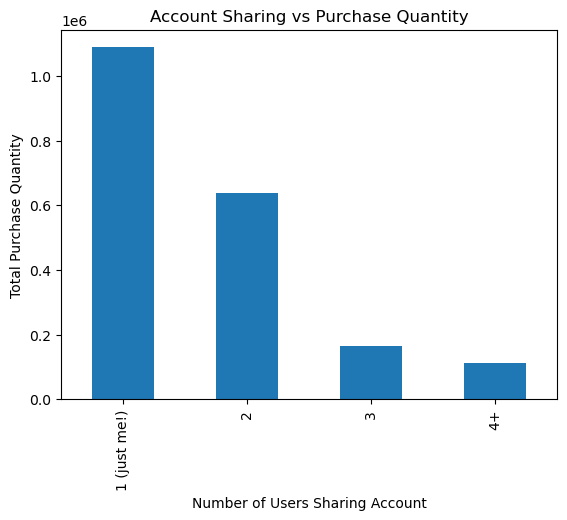

In [6]:
import matplotlib.pyplot as plt

group1['sum'].plot(kind='bar')
plt.xlabel('Number of Users Sharing Account')
plt.ylabel('Total Purchase Quantity')
plt.title('Account Sharing vs Purchase Quantity')
plt.show()

In [7]:
from scipy.stats import f_oneway

groups = [g['Quantity'].values for _, g in df.groupby('No.of Users')]
f_stat, p_val = f_oneway(*groups)

print("F-stat:", f_stat)
print("p-value:", p_val)

F-stat: 5.476764716500737
p-value: 0.0009254249842029225


### Test-2

In [8]:
import pandas as pd

# Copy dataset
df2 = df.copy()

# Clean Family Size (extract numeric)
df2['family_size_clean'] = df2['Family Size'].str.extract(r'(\d+)')

# Standardize "4+" case if exists
df2['family_size_clean'] = df2['family_size_clean'].replace('4', '4+')

# Convert to category
df2['family_size_clean'] = df2['family_size_clean'].astype('category')


# Clean Age Group (already grouped, just simplify text)
df2['age_group'] = df2['Age'].str.replace(' years', '', regex=False)

df2['age_group'] = df2['age_group'].astype('category')


# Ensure Quantity is numeric
df2['Quantity'] = pd.to_numeric(df2['Quantity'], errors='coerce')

# Drop missing values
df2 = df2.dropna(subset=['family_size_clean', 'age_group', 'Quantity'])

In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Build model (with interaction)
model = ols('Quantity ~ C(family_size_clean) + C(age_group) + C(family_size_clean):C(age_group)', data=df2).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                         sum_sq         df           F  \
C(family_size_clean)               3.223094e+01        3.0   17.635511   
C(age_group)                       4.142357e+02        5.0  135.992158   
C(family_size_clean):C(age_group)  1.097183e+02       15.0   12.006715   
Residual                           1.120360e+06  1839051.0         NaN   

                                          PR(>F)  
C(family_size_clean)                1.920145e-11  
C(age_group)                       1.124345e-144  
C(family_size_clean):C(age_group)   2.277405e-30  
Residual                                     NaN  


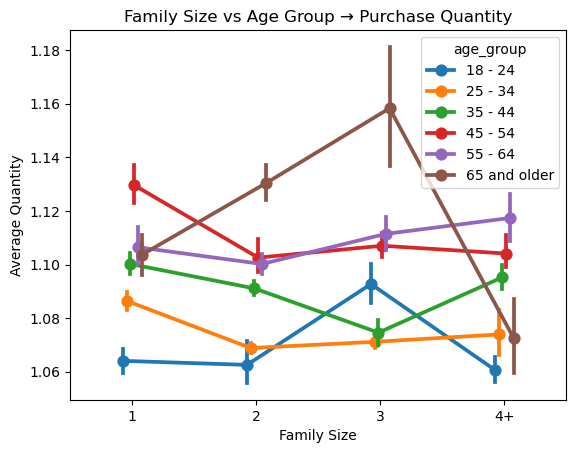

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.pointplot(data=df2,
              x='family_size_clean',
              y='Quantity',
              hue='age_group',
              dodge=True)

plt.title('Family Size vs Age Group → Purchase Quantity')
plt.xlabel('Family Size')
plt.ylabel('Average Quantity')

plt.show()

In [17]:
group2 = df.groupby('Family Size')['Quantity'].agg(['sum','mean','count'])
print(group2)

                   sum      mean   count
Family Size                             
1 (just me!)  385917.0  1.095518  352269
2             644124.0  1.085782  593235
3             382357.0  1.085427  352264
4+            590118.0  1.090172  541307


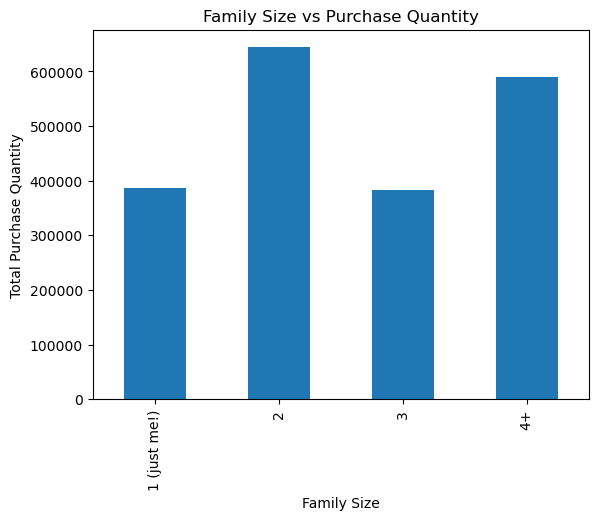

In [18]:
group2['sum'].plot(kind='bar')
plt.xlabel('Family Size')
plt.ylabel('Total Purchase Quantity')
plt.title('Family Size vs Purchase Quantity')
plt.show()

In [20]:
groups = [g['Quantity'].values for _, g in df.groupby('Family Size')]
f_stat, p_val = f_oneway(*groups)

In [21]:

print("F-stat:", f_stat)
print("p-value:", p_val)

F-stat: 14.393509735077638
p-value: 2.2536469978397846e-09


In [22]:
print(df['Acc Usage'].unique())

['Less than 5 times per month' 'More than 10 times per month'
 '5 - 10 times per month']


### Test-3

In [11]:
import pandas as pd

df2 = df.copy()

# Clean Acc Usage (already categorical, just convert)
df2['Acc Usage'] = df2['Acc Usage'].astype('category')

# Clean Income (categorical)
df2['Income'] = df2['Income'].astype('category')

# Ensure Quantity is numeric
df2['Quantity'] = pd.to_numeric(df2['Quantity'], errors='coerce')

# Drop missing values
df2 = df2.dropna(subset=['Acc Usage', 'Income', 'Quantity'])

In [12]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Build model
model = ols('Quantity ~ C(Q("Acc Usage")) + C(Income) + C(Q("Acc Usage")):C(Income)', data=df2).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                   sum_sq         df          F        PR(>F)
C(Q("Acc Usage"))            1.006855e+01        2.0   8.261329  2.583250e-04
C(Income)                    1.134209e+02        6.0  31.020929  1.702779e-37
C(Q("Acc Usage")):C(Income)  9.766488e+01       12.0  13.355806  4.642462e-28
Residual                     1.120680e+06  1839054.0        NaN           NaN


In [14]:
first_50 = df.head(50)

In [15]:
first_50.to_csv("C://Users//vaish//Desktop//MKT 4990//first_50.csv", index=False)

In [23]:
group3 = df.groupby('Acc Usage')['Quantity'].agg(['sum','mean','count'])
print(group3)

                                   sum      mean   count
Acc Usage                                               
5 - 10 times per month        837814.0  1.090638  768187
Less than 5 times per month   753594.0  1.084876  694636
More than 10 times per month  411108.0  1.092640  376252


In [24]:
mapping = {
    '5 - 10 times per month':1,
    'Less than 5 times per month':2,
    'More than 10 times per month':3
}

df['Usage_Num'] = df['Acc Usage'].map(mapping)

In [25]:
corr = df[['Usage_Num','Quantity']].corr()
print(corr)

           Usage_Num  Quantity
Usage_Num   1.000000  0.000056
Quantity    0.000056  1.000000
